## Step1 :- Load the dataset & Understanding the dataset

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/hasya/OneDrive/Desktop/Synent Technologies/TASK3/DATA/NIFTY50_all.csv")
df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [90]:
total_rows = df.shape[0]
total_rows

total_companies = df['Symbol'].nunique()
total_companies

df['Date'] = pd.to_datetime(df['Date'])

start_date = df['Date'].min()
end_date = df['Date'].max()

print("Date range:", start_date, "to", end_date)



Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00


## Step2 :- Selecting Important Columns

In [92]:

df = df[['Date', 'Symbol', 'Close', 'Volume']]

print("\nSelected Columns:")
print(df.columns)

print("\nPreview after column selection:")
df.head()



Selected Columns:
Index(['Date', 'Symbol', 'Close', 'Volume'], dtype='object')

Preview after column selection:


,Date,Symbol,Close,Volume
0,2007-11-27,MUNDRAPORT,962.90,27294366
1,2007-11-28,MUNDRAPORT,893.90,4581338
2,2007-11-29,MUNDRAPORT,884.20,5124121
3,2007-11-30,MUNDRAPORT,921.55,4609762
4,2007-12-03,MUNDRAPORT,969.30,2977470


## Step3 :- Preparing Date for Main Task

In [93]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

print("\nData after date processing:")
df.head()


Data after date processing:


,Symbol,Close,Volume
Date,,,
2000-01-03,HDFC,293.50,22744
2000-01-03,IOC,270.85,23700
2000-01-03,WIPRO,2724.20,1599
2000-01-03,TELCO,216.75,676126
2000-01-03,TITAN,155.70,23000


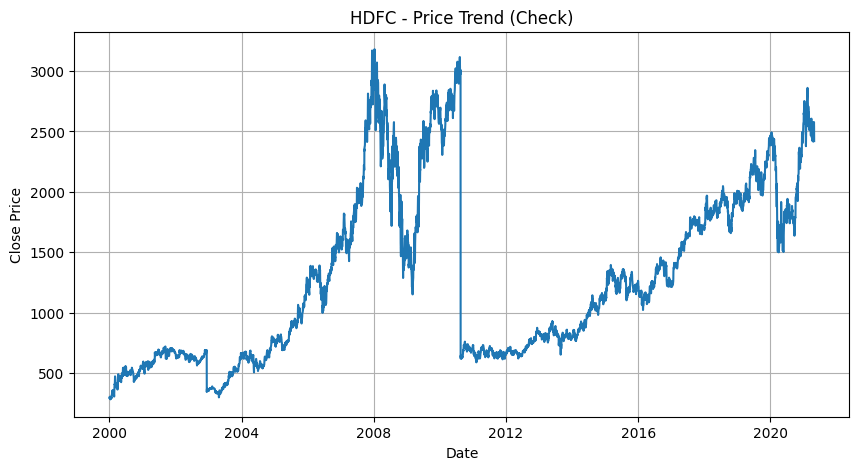

In [94]:
sample_company = df['Symbol'].value_counts().index[0]

company_data = df[df['Symbol'] == sample_company]

plt.figure(figsize=(10,5))

plt.plot(company_data.index, company_data['Close'])

plt.title(f"{sample_company} - Price Trend (Check)")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid()
plt.show()

## Step4 :- Handling Missing Value 

In [96]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df['Close'] = df['Close'].ffill()

df['Volume'] = df['Volume'].fillna(0)
df = df.dropna(subset=['Symbol'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

df = df.dropna()


Missing values before cleaning:
Symbol    0
Close     0
Volume    0
dtype: int64

Missing values after cleaning:
Symbol    0
Close     0
Volume    0
dtype: int64


## Step5 :- Calculating average price for top 10 company & lowest 10 company from dataset 

In [100]:
company_avg = df.groupby('Symbol')['Close'].mean()

company_avg = company_avg.sort_values(ascending=False)

company_avg = company_avg.reset_index()
company_avg.columns = ['Symbol', 'Avg_Close']

print("\nTop companies by average price:")
print(company_avg.head(10))


Top companies by average price:
       Symbol    Avg_Close
0   NESTLEIND  7512.039647
1   EICHERMOT  6751.063167
2    SHREECEM  6565.809539
3  INFOSYSTCH  3323.156028
4      MARUTI  2925.005094
5  BAJAJFINSV  2758.657451
6  HEROMOTOCO  2665.182060
7  BAJFINANCE  2627.858937
8  BAJAJ-AUTO  2190.412196
9  ULTRACEMCO  2150.926570


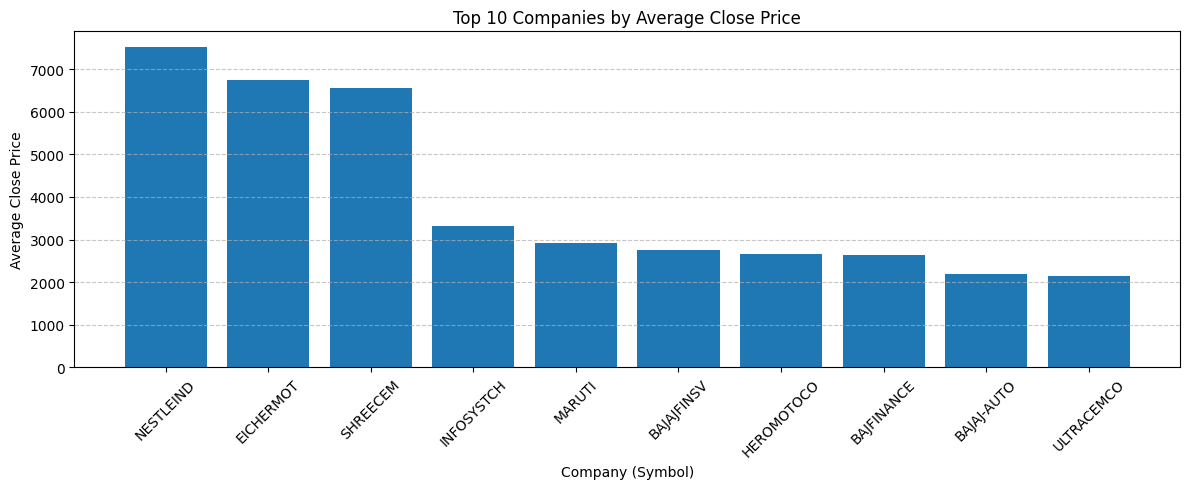

In [101]:
top_companies = company_avg.head(10)

plt.figure(figsize=(12,5))

plt.bar(top_companies['Symbol'], top_companies['Avg_Close'])

plt.title("Top 10 Companies by Average Close Price")
plt.xlabel("Company (Symbol)")
plt.ylabel("Average Close Price")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [102]:
print("\nLowest value companies:")
print(company_avg.tail(10))


Lowest value companies:
        Symbol   Avg_Close
55       TISCO  210.248660
56  BAJAUTOFIN  196.659747
57        VEDL  183.293489
58     UTIBANK  163.126203
59    HINDALCO  159.223959
60      BHARTI  155.404821
61        NTPC  150.992723
62       TELCO  145.982332
63   POWERGRID  141.382152
64    KOTAKMAH  124.575797


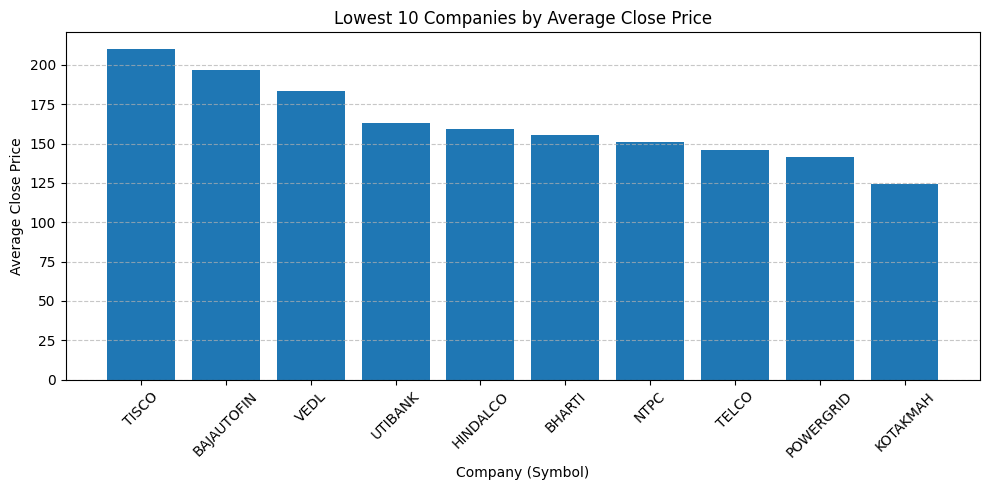

In [103]:
last_companies = company_avg.tail(10)

plt.figure(figsize=(10,5))

plt.bar(last_companies['Symbol'], last_companies['Avg_Close'])

plt.title("Lowest 10 Companies by Average Close Price")
plt.xlabel("Company (Symbol)")
plt.ylabel("Average Close Price")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step6 :- Selecting Top and Medium Companies ((Means Top companies vs mid-level companies))

In [104]:
top_5 = company_avg.head(5)

medium_5 = company_avg.iloc[5:10]

selected_companies = pd.concat([top_5, medium_5])

selected_symbols = selected_companies['Symbol'].tolist()

print("\nHigh Value Companies:")
print(top_5)

print("\nMedium Value Companies:")
print(medium_5)


High Value Companies:
       Symbol    Avg_Close
0   NESTLEIND  7512.039647
1   EICHERMOT  6751.063167
2    SHREECEM  6565.809539
3  INFOSYSTCH  3323.156028
4      MARUTI  2925.005094

Medium Value Companies:
       Symbol    Avg_Close
5  BAJAJFINSV  2758.657451
6  HEROMOTOCO  2665.182060
7  BAJFINANCE  2627.858937
8  BAJAJ-AUTO  2190.412196
9  ULTRACEMCO  2150.926570


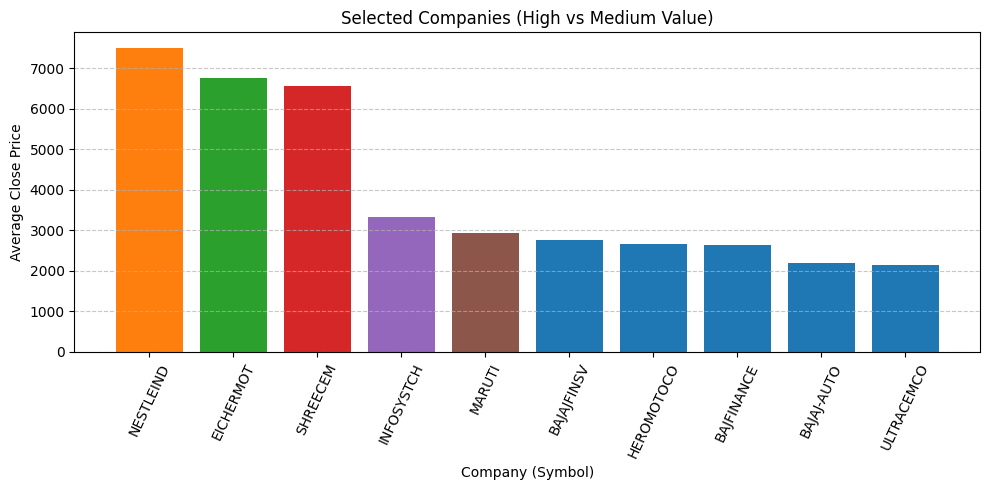

In [105]:
plt.figure(figsize=(10,5))

plt.bar(selected_companies['Symbol'], selected_companies['Avg_Close'])

for i in range(5):
    plt.bar(top_5['Symbol'].iloc[i], top_5['Avg_Close'].iloc[i])

plt.title("Selected Companies (High vs Medium Value)")
plt.xlabel("Company (Symbol)")
plt.ylabel("Average Close Price")

plt.xticks(rotation=65)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step7 :- Comparing Multiple Companies

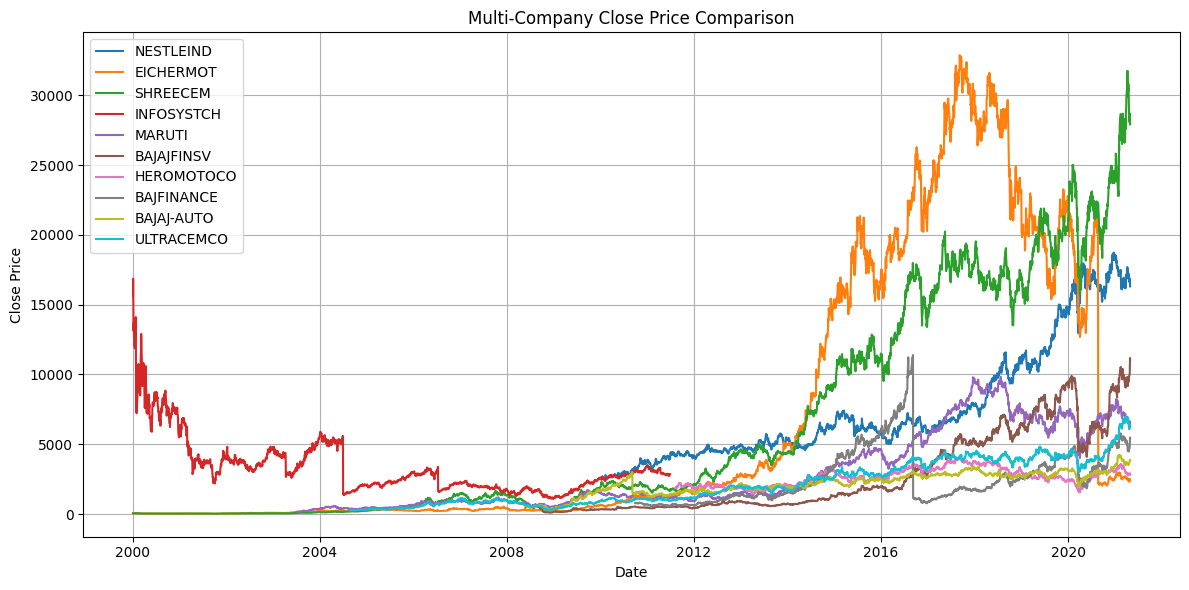

In [106]:
# filter dataset for selected companies
filtered_df = df[df['Symbol'].isin(selected_symbols)]

plt.figure(figsize=(12,6))

# plot each company
for symbol in selected_symbols:
    company_data = filtered_df[filtered_df['Symbol'] == symbol]
    
    plt.plot(company_data.index, company_data['Close'], label=symbol)

plt.title("Multi-Company Close Price Comparison")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Step8 :- Analyzing 2-2 Company from Top and Medium Company

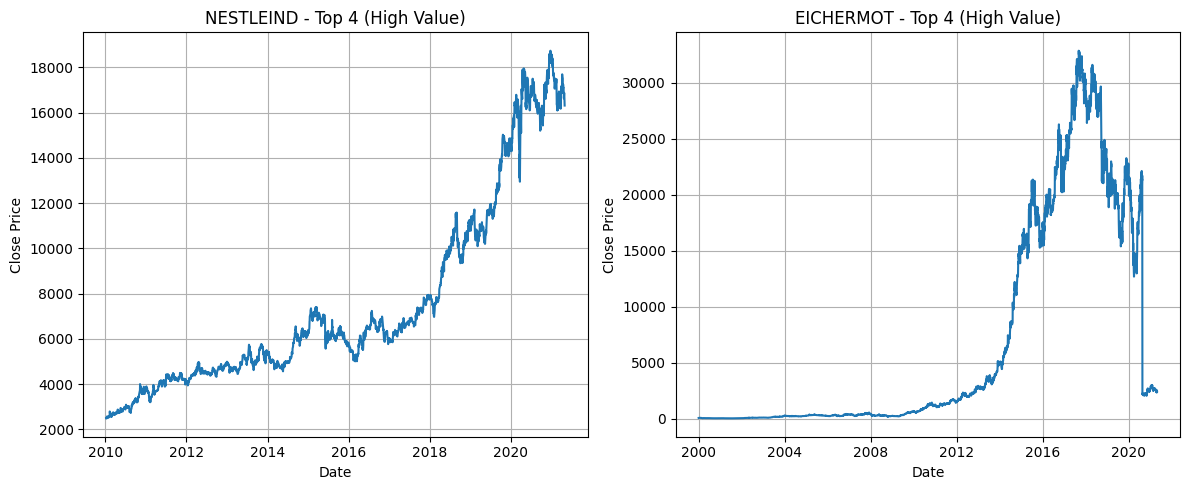

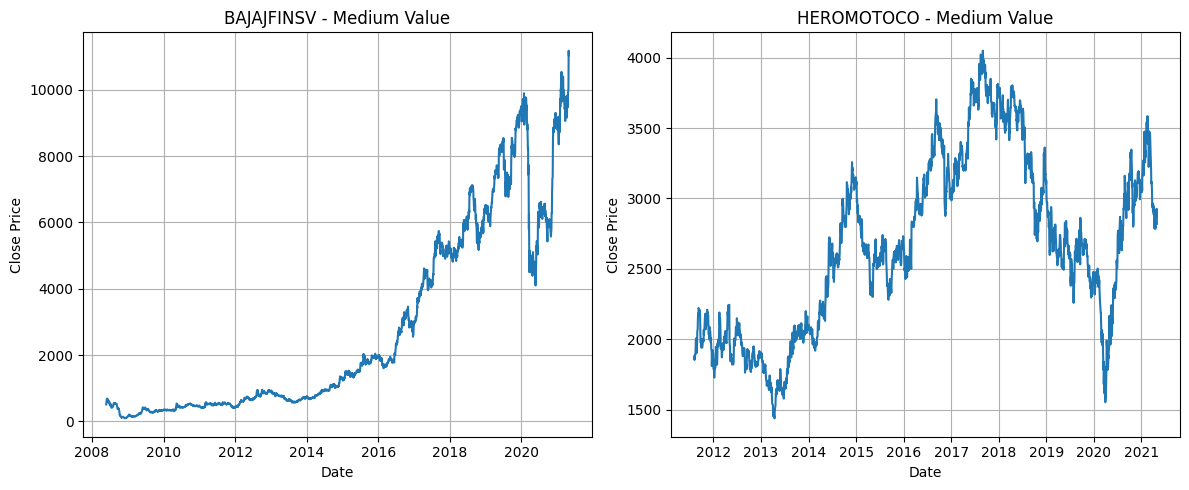

In [ ]:
top_2 = company_avg.head(2)

medium_2 = company_avg.iloc[5:7]

selected_companies2 = pd.concat([top_2, medium_2])

selected_symbols2 = selected_companies2['Symbol'].tolist()

symbols = selected_symbols2

top_symbols = top_2['Symbol'].tolist()
medium_symbols = medium_2['Symbol'].tolist()

for i in range(0, len(symbols), 2):
    
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    
    for j in range(2):
        if i + j < len(symbols):
            symbol = symbols[i + j]
            company_data = df[df['Symbol'] == symbol]
           
            if symbol in top_symbols:
                label = "Top 4 (High Value)"
            else:
                label = "Medium Value"
            
            axes[j].plot(company_data.index, company_data['Close'])
            axes[j].set_title(f"{symbol} - {label}")
            axes[j].set_xlabel("Date")
            axes[j].set_ylabel("Close Price")
            axes[j].grid()
    
    plt.tight_layout()
    plt.show()

## Step9 :-Identifying Trends Using Moving Average 

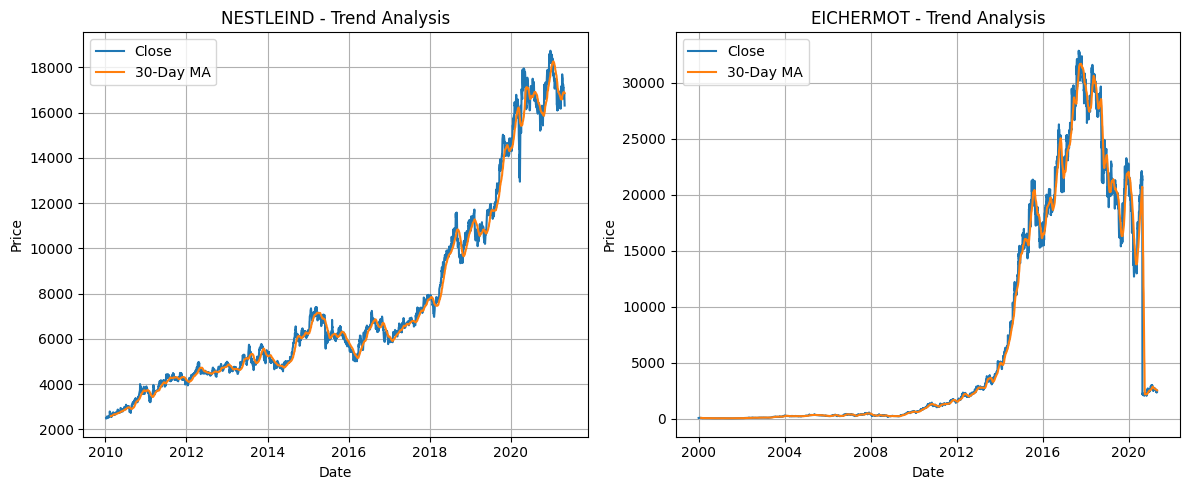

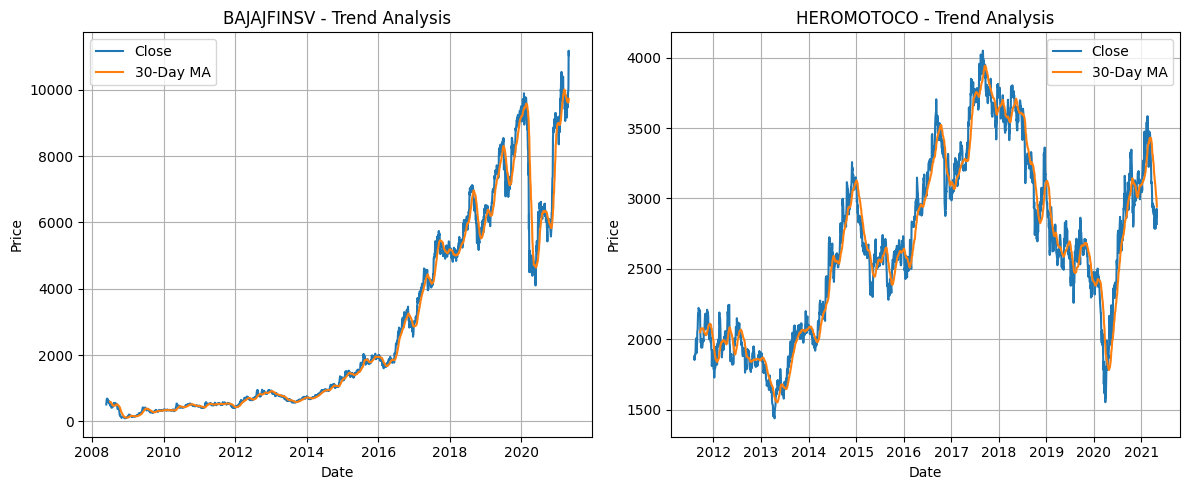

In [107]:
for i in range(0, len(symbols), 2):
    
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    
    for j in range(2):
        if i + j < len(symbols):
            symbol = symbols[i + j]
            company_data = df[df['Symbol'] == symbol].copy()
           
            company_data['MA_30'] = company_data['Close'].rolling(30).mean()
            
            axes[j].plot(company_data.index, company_data['Close'], label='Close')
            axes[j].plot(company_data.index, company_data['MA_30'], label='30-Day MA')
            
            axes[j].set_title(f"{symbol} - Trend Analysis")
            axes[j].set_xlabel("Date")
            axes[j].set_ylabel("Price")
            
            axes[j].legend()
            axes[j].grid()
    
    plt.tight_layout()
    plt.show()

## Step10 :- Analyzing Risk Using Volatility

In [ ]:

volatility = df[df['Symbol'].isin(selected_symbols2)] \
                .groupby('Symbol')['Close'].std()

volatility = volatility.sort_values(ascending=False)

print("\nVolatility (Standard Deviation):")
print(volatility)


Volatility (Standard Deviation):
Symbol
EICHERMOT     9702.651623
NESTLEIND     4182.705331
BAJAJFINSV    2873.522615
HEROMOTOCO     621.085091
Name: Close, dtype: float64


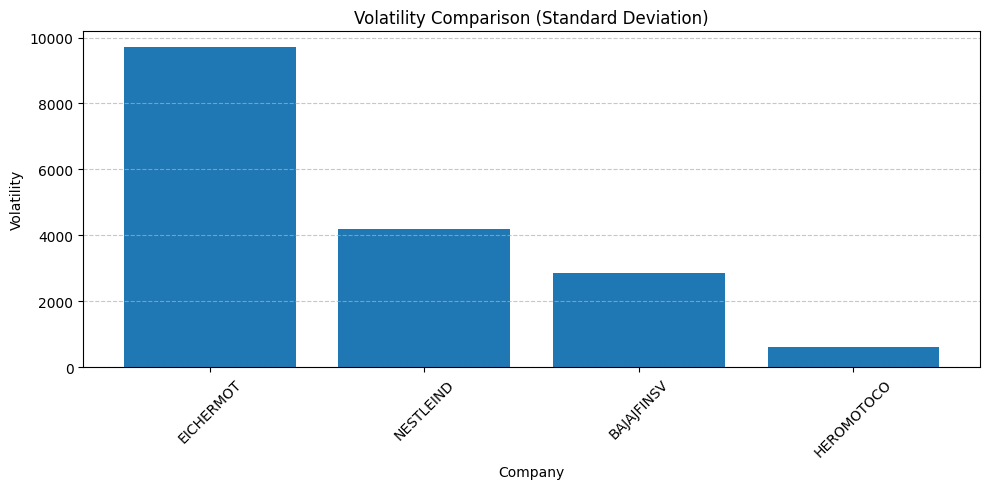

In [48]:
plt.figure(figsize=(10,5))

plt.bar(volatility.index, volatility.values)

plt.title("Volatility Comparison (Standard Deviation)")
plt.xlabel("Company")
plt.ylabel("Volatility")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step11 :- Analyzing Long-Term Trends (Monthly & yearly resampling)

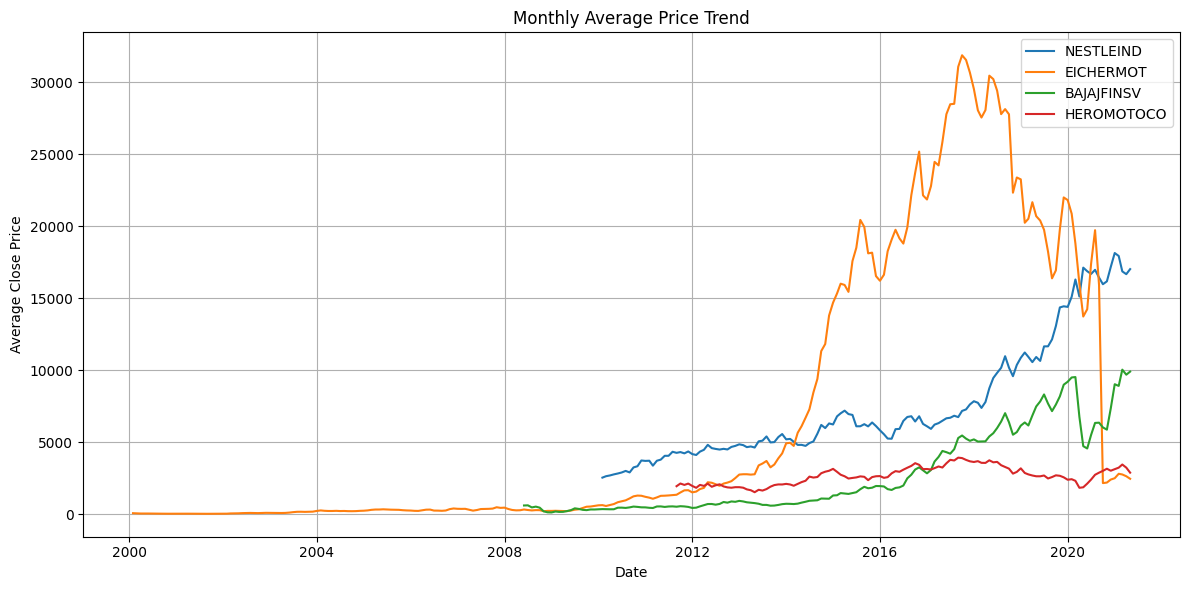

In [108]:
filtered_df = df[df['Symbol'].isin(selected_symbols2)]

plt.figure(figsize=(12,6))

# The loop below represents the month average for the top 2 and medium 2 companies
for symbol in selected_symbols2:

# The loop below represents the month average for only the top 2 companies (Not the medium 2)
# for symbol in selected_symbols2[:2]:
    company_data = filtered_df[filtered_df['Symbol'] == symbol]
    
    monthly_data = company_data['Close'].resample('ME').mean()
    
    plt.plot(monthly_data.index, monthly_data, label=symbol)

plt.title("Monthly Average Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

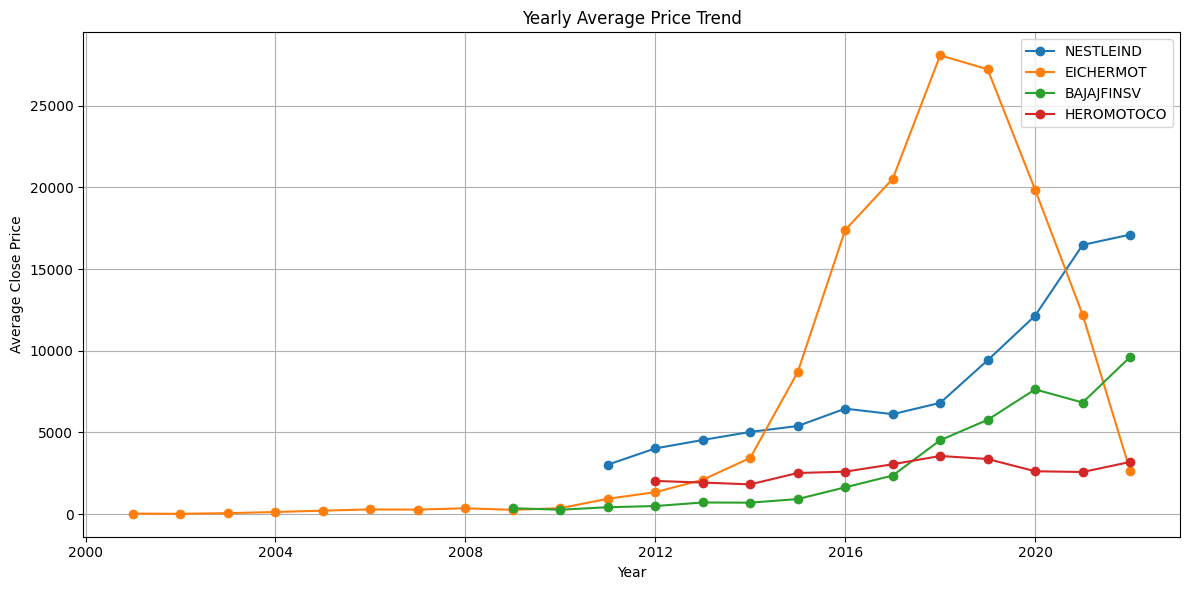

In [109]:
plt.figure(figsize=(12,6))
# The loop below represents the yearly average for the top 2 and medium 2 companies
for symbol in selected_symbols2:

# The loop below represents the yearly average for only the top 2 companies (Not the medium 2)
# for symbol in selected_symbols2[:2]:
    company_data = filtered_df[filtered_df['Symbol'] == symbol]
    
    # yearly average
    yearly_data = company_data['Close'].resample('YE').mean()
    
    plt.plot(yearly_data.index, yearly_data, marker='o', label=symbol)

plt.title("Yearly Average Price Trend")
plt.xlabel("Year")
plt.ylabel("Average Close Price")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Step12 :- Comparing Top vs Medium Companies

In [110]:
high_symbols = top_2['Symbol'].tolist()
medium_symbols = medium_2['Symbol'].tolist()

high_df = df[df['Symbol'].isin(high_symbols)]
medium_df = df[df['Symbol'].isin(medium_symbols)]

high_trend = high_df.groupby('Date')['Close'].mean().resample('ME').mean()
medium_trend = medium_df.groupby('Date')['Close'].mean().resample('ME').mean()

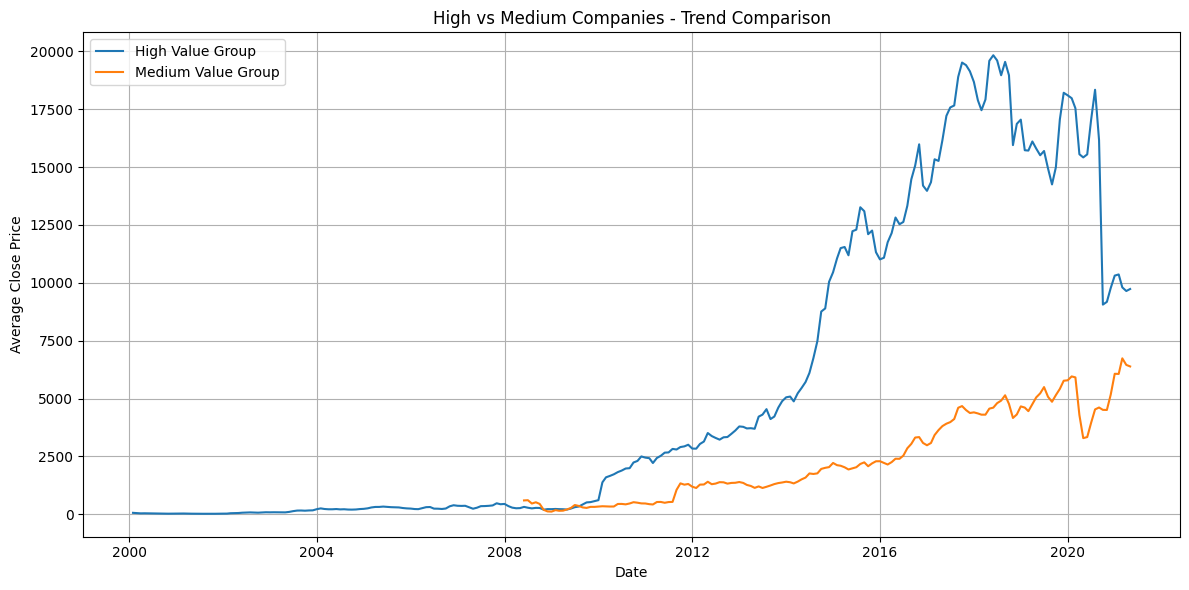

In [111]:
plt.figure(figsize=(12,6))

plt.plot(high_trend.index, high_trend, label='High Value Group')
plt.plot(medium_trend.index, medium_trend, label='Medium Value Group')

plt.title("High vs Medium Companies - Trend Comparison")
plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Step13 :- Analyzing Long-Term Trends


Data prepared for forecasting: NESTLEIND
        Date    Close  Time
0 2010-01-08  2494.65     0
1 2010-01-11  2498.95     1
2 2010-01-12  2502.85     2
3 2010-01-13  2489.35     3
4 2010-01-14  2568.20     4
5 2010-01-15  2513.50     5
6 2010-01-18  2536.15     6
7 2010-01-19  2556.10     7
8 2010-01-20  2542.50     8
9 2010-01-21  2526.20     9


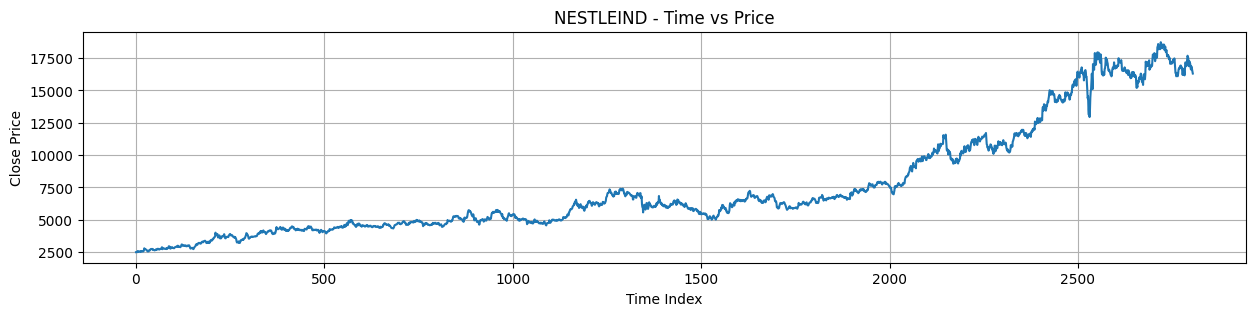

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# select one company
symbol = high_symbols[0]

# filter data
company_data = df[df['Symbol'] == symbol].copy()

# reset index (Date → column)
company_data = company_data.reset_index()

# sort by date (important safety step)
company_data = company_data.sort_values('Date')

# create numeric time index
company_data['Time'] = np.arange(len(company_data))

# preview
print(f"\nData prepared for forecasting: {symbol}")
print(company_data[['Date', 'Close', 'Time']].head(10))

plt.figure(figsize=(15,3))

plt.plot(company_data['Time'], company_data['Close'])

plt.title(f"{symbol} - Time vs Price")
plt.xlabel("Time Index")
plt.ylabel("Close Price")

plt.grid()
plt.show()

## Step14 :- Detecting Seasonality Patterns

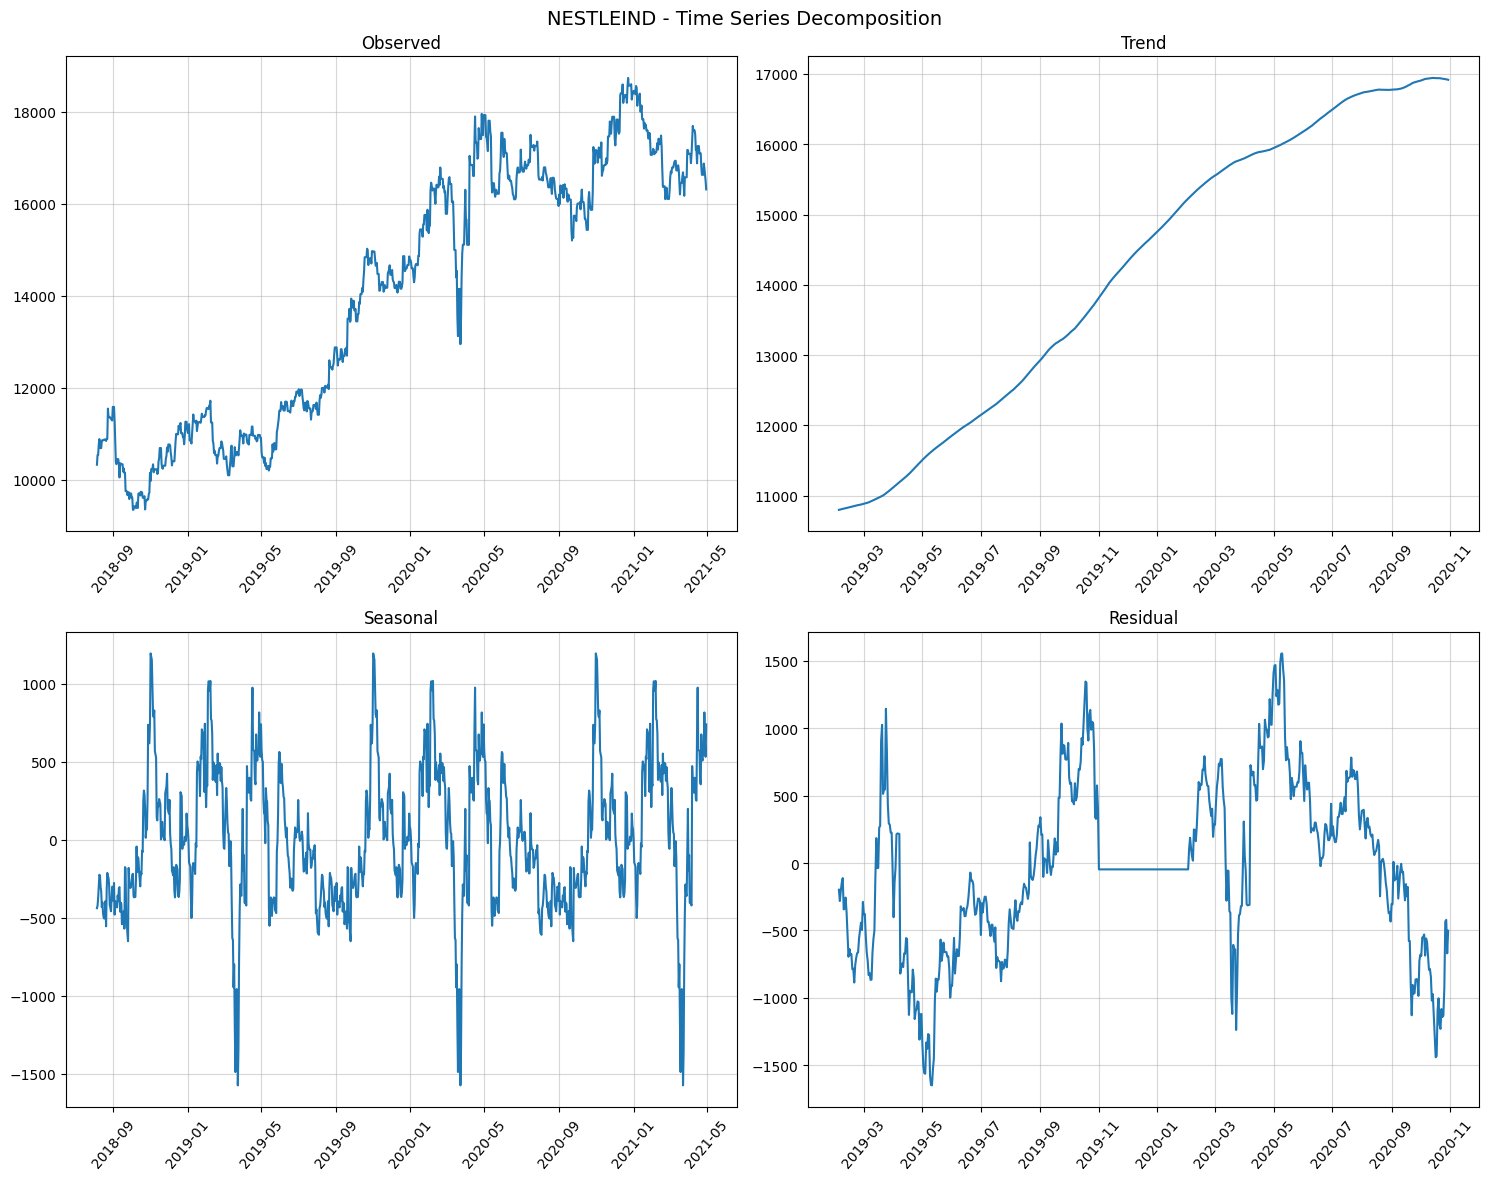

In [112]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

symbol = selected_symbols2[0]
company_data = df[df['Symbol'] == symbol].copy()
company_data = company_data.sort_index()

ts = company_data['Close'].asfreq('D')
ts = ts.ffill()
ts = ts.tail(1000)

result = seasonal_decompose(ts, model='additive', period=365)
fig, axes = plt.subplots(2, 2, figsize=(15,12))

axes[0,0].plot(result.observed)
axes[0,0].set_title("Observed")

axes[0,1].plot(result.trend)
axes[0,1].set_title("Trend")

axes[1,0].plot(result.seasonal)
axes[1,0].set_title("Seasonal")

axes[1,1].plot(result.resid)
axes[1,1].set_title("Residual")

for ax in axes.flatten():
    ax.grid(alpha=0.5)
    ax.tick_params(axis='x', rotation=50)
    
plt.suptitle(f"{symbol} - Time Series Decomposition", fontsize=14)
plt.tight_layout()
plt.show()

## Step15 :- Forecasting using model

C:\Users\hasya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\hasya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


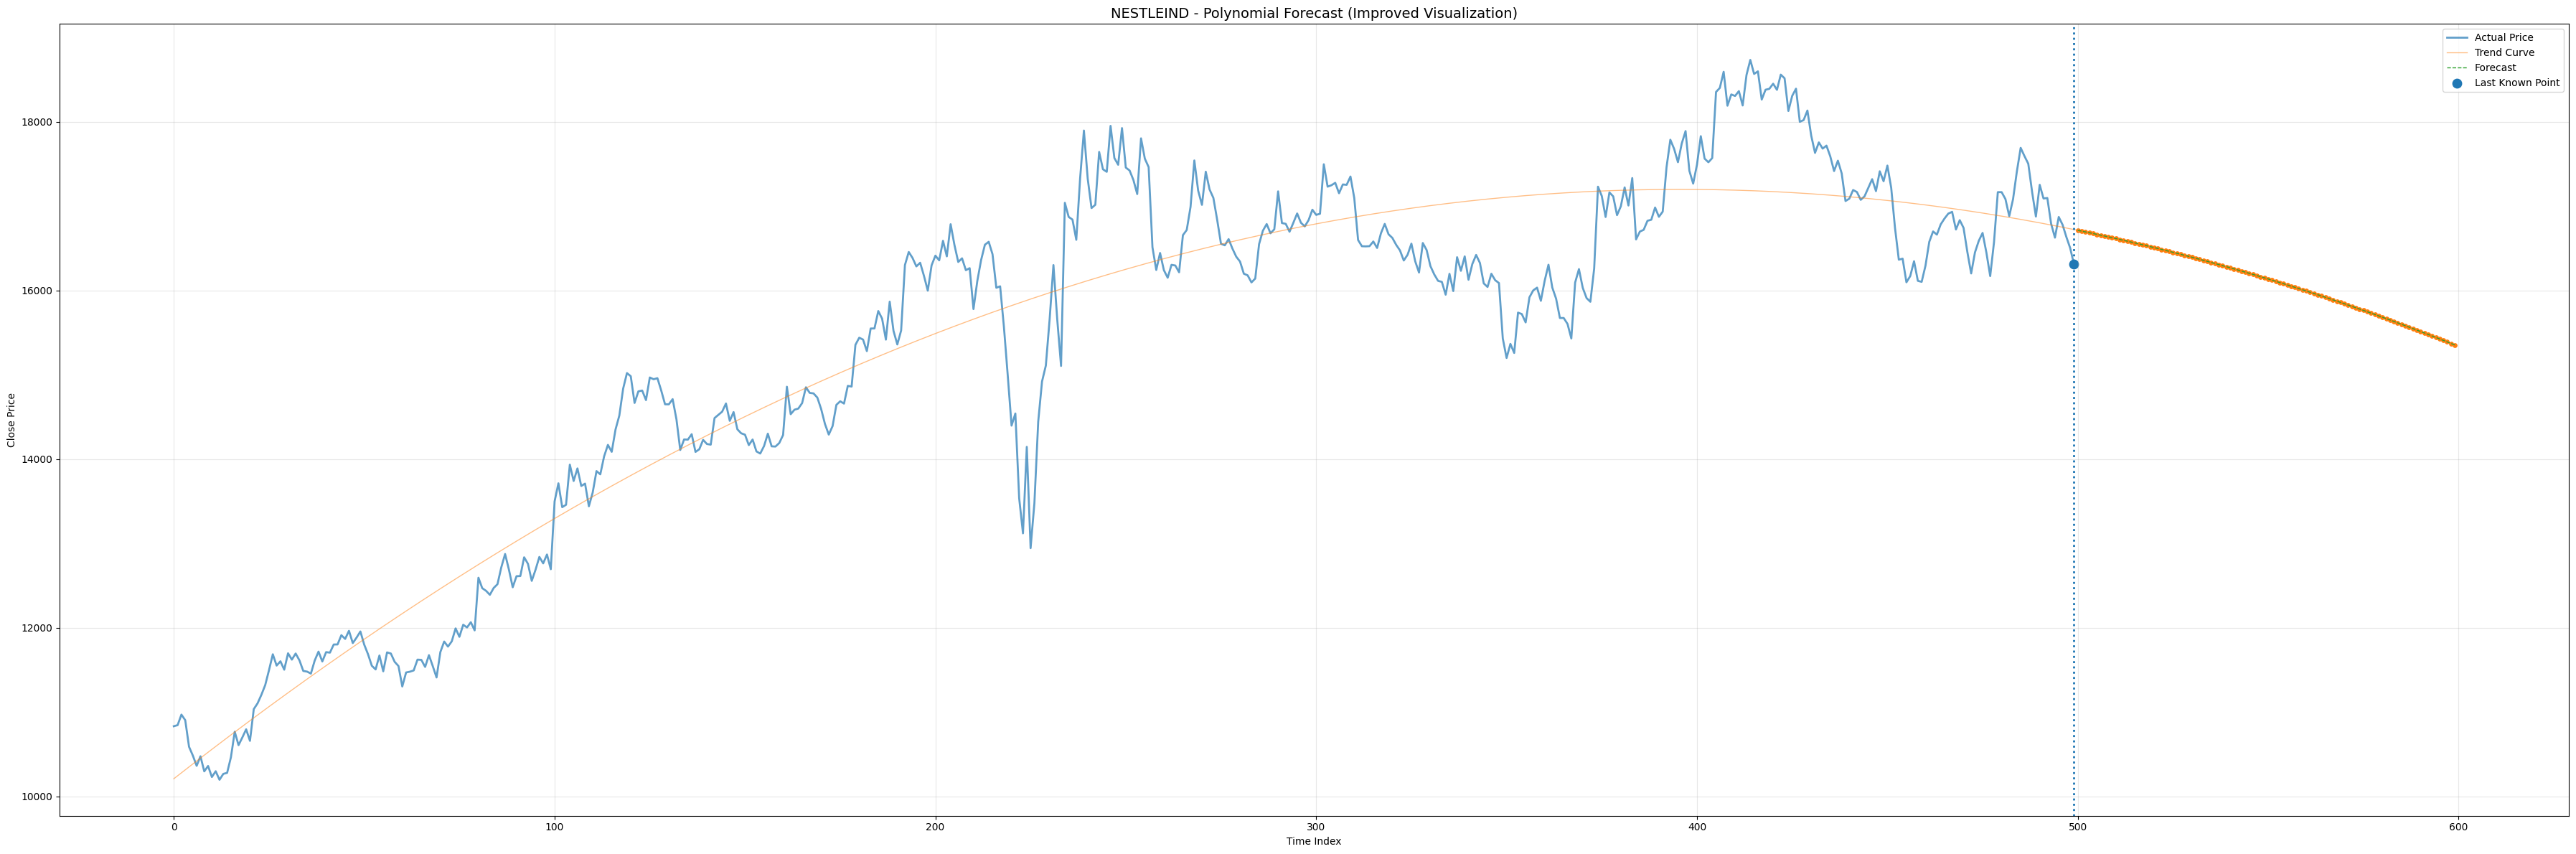

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

company_data_recent = company_data.tail(500).copy()
company_data_recent = company_data_recent.reset_index()

company_data_recent['Time'] = np.arange(len(company_data_recent))

X = company_data_recent[['Time']]
y = company_data_recent['Close']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

last_time = company_data_recent['Time'].iloc[-1]

future_time = np.arange(last_time + 1, last_time + 101).reshape(-1, 1)
future_poly = poly.transform(future_time)

forecast = model.predict(future_poly)

full_time = np.concatenate([X.values.flatten(), future_time.flatten()])
full_time = full_time.reshape(-1, 1)

full_poly = poly.transform(full_time)
smooth_curve = model.predict(full_poly)

plt.figure(figsize=(36,12))
plt.plot(
    company_data_recent['Time'],
    company_data_recent['Close'],
    linewidth=2,
    alpha=0.7,
    label='Actual Price'
)

plt.plot(
    full_time,
    smooth_curve,
    linestyle='-',
    linewidth=1,
    alpha=0.5,
    label='Trend Curve'
)

plt.plot(
    future_time,
    forecast,
    linestyle='--',
    linewidth=1,
    label='Forecast'
)

plt.scatter(
    last_time,
    company_data_recent['Close'].iloc[-1],
    s=80,
    label='Last Known Point'
)

plt.scatter(future_time, forecast, s=15)
plt.axvline(x=last_time, linestyle=':', linewidth=2)
plt.title(f"{symbol} - Polynomial Forecast (Improved Visualization)", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Close Price")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step16 :- Final Insights

In [117]:
print("\n" + "="*50)
print(" FINAL TIME SERIES INSIGHTS")
print("="*50)

start_price = company_data['Close'].iloc[0]
end_price = company_data['Close'].iloc[-1]

print("\nTrend Analysis:")
print(f"Start Price : {start_price:.2f}")
print(f"End Price   : {end_price:.2f}")

if end_price > start_price:
    print("Overall Trend: Increasing (Growth observed)")
else:
    print("Overall Trend: Decreasing (Decline observed)")
    
most_risky = volatility.idxmax()
least_risky = volatility.idxmin()

print("\nVolatility Analysis:")
print(f"Most Volatile (High Risk) : {most_risky}")
print(f"Least Volatile (Stable)   : {least_risky}")

print("\nGroup Performance:")

high_last = high_trend.iloc[-1]
medium_last = medium_trend.iloc[-1]

print(f"High Value Group Final Avg   : {high_last:.2f}")
print(f"Medium Value Group Final Avg : {medium_last:.2f}")

if high_last > medium_last:
    print("High-value companies perform better overall")
else:
    print("Medium-value companies perform better overall")

print("\n" + "="*50)


 FINAL TIME SERIES INSIGHTS

Trend Analysis:
Start Price : 2494.65
End Price   : 16309.25
Overall Trend: Increasing (Growth observed)

Volatility Analysis:
Most Volatile (High Risk) : EICHERMOT
Least Volatile (Stable)   : HEROMOTOCO

Group Performance:
High Value Group Final Avg   : 9731.32
Medium Value Group Final Avg : 6385.03
High-value companies perform better overall

